#**Importy**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
base_path = Path('/content/drive/MyDrive/CSV')


#**Wstępna Analiza**

In [3]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [4]:
print(titanic_df.head())

             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   

             SibSp  Parch            Ticket     Fare Cabin Embarked  
PassengerId                                                          
1                1      0         A/5 21171   7.2500   NaN        S

In [5]:
print(titanic_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB
None


In [6]:
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,98
Cabin,687


#**Wykresy**

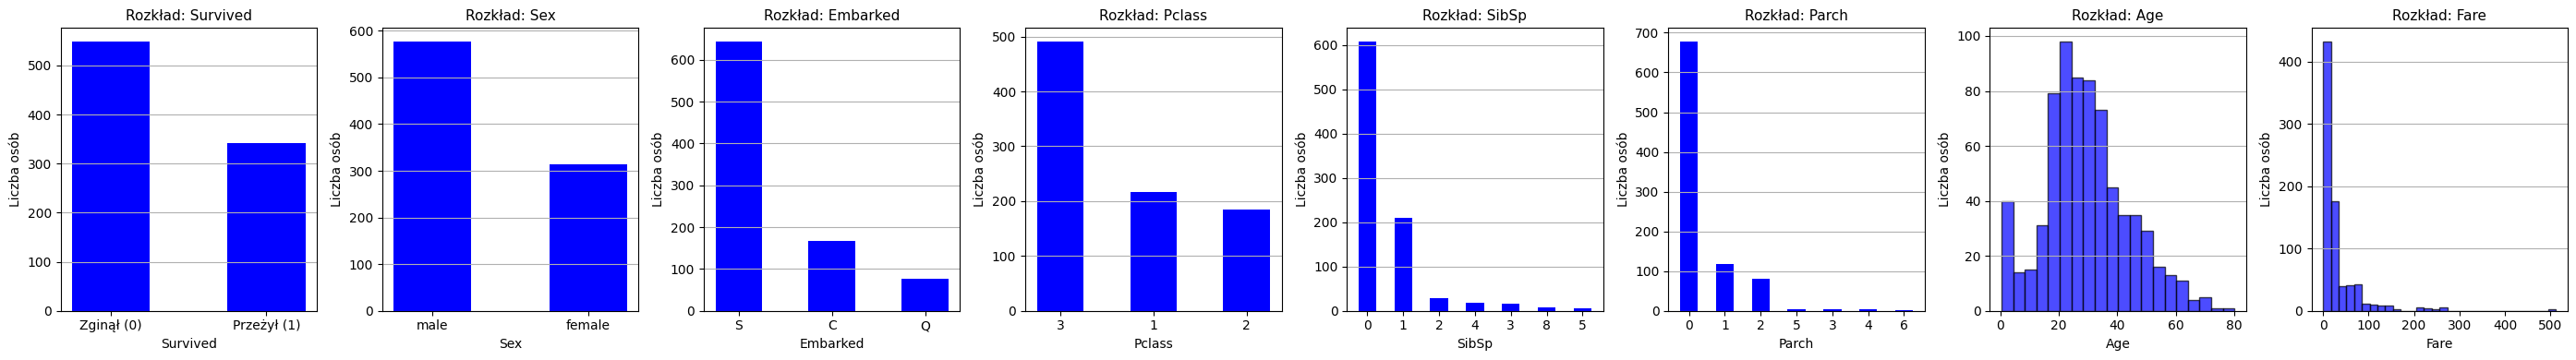

In [7]:
def categorical_distribution(
df,
    cat_cols=[
        "Survived",
        "Sex",
        "Embarked",
        "Pclass",
        "SibSp",
        "Parch",
    ],
    num_cols=["Age", "Fare"],
):
    all_cols = cat_cols + num_cols
    fig, axes = plt.subplots(1, len(all_cols), figsize=(3.5 * len(all_cols), 4))

    for ax, col in zip(axes, all_cols):
        clean_series = df[col].dropna()

        if col in cat_cols:
            counts = clean_series.value_counts()
            labels = counts.index.astype(str)

            if col == "Survived":
                labels = counts.index.map({0: "Zginął (0)", 1: "Przeżył (1)"})
            bars = ax.bar(labels, counts.values, color="blue", width=0.5)

            ax.set_title(f"Rozkład: {col}", fontsize=11)
            ax.set_xlabel(col, fontsize=10)
            ax.set_ylabel("Liczba osób", fontsize=10)
            ax.grid(axis="y")

        else:
            ax.hist(
                clean_series,
                bins=20 if col == "Age" else 30,
                color="blue",
                edgecolor="black",
                alpha=0.7,
            )

            ax.set_title(f"Rozkład: {col}", fontsize=11)
            ax.set_xlabel(col, fontsize=10)
            ax.set_ylabel("Liczba osób", fontsize=10)
            ax.grid(axis="y")

    plt.tight_layout()
    plt.show()
categorical_distribution(titanic_df)

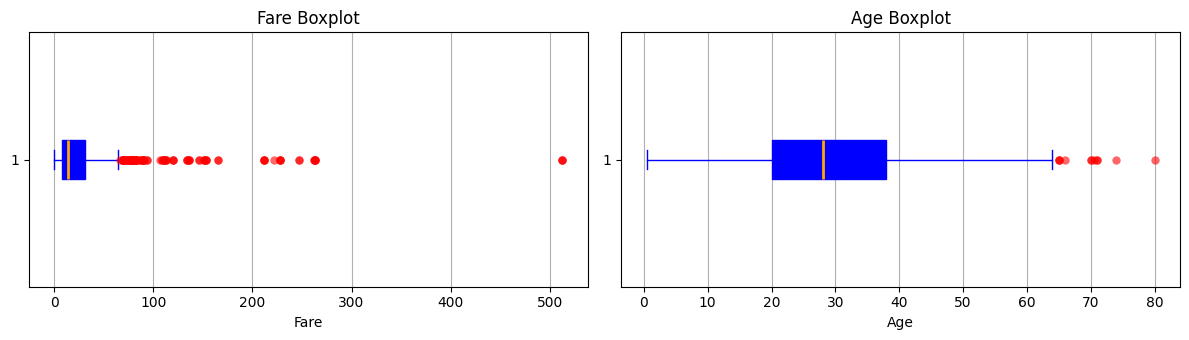

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].boxplot(
    titanic_df["Fare"].dropna(),
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="blue", color="blue"),
    medianprops=dict(color="orange", linewidth=2),
    whiskerprops=dict(color="blue"),
    capprops=dict(color="blue"),
    flierprops=dict(
        marker="o", markerfacecolor="red", markeredgecolor="none", alpha=0.6
    ),
)
axes[0].set_title("Fare Boxplot", fontsize=12)
axes[0].set_xlabel("Fare", fontsize=10)
axes[0].grid(axis="x")

axes[1].boxplot(
    titanic_df["Age"].dropna(),
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="blue", color="blue"),
    medianprops=dict(color="orange", linewidth=2),
    whiskerprops=dict(color="blue"),
    capprops=dict(color="blue"),
    flierprops=dict(
        marker="o", markerfacecolor="red", markeredgecolor="none", alpha=0.6
    ),
)
axes[1].set_title("Age Boxplot", fontsize=12)
axes[1].set_xlabel("Age", fontsize=10)
axes[1].grid(axis="x")

plt.tight_layout()
plt.show()

Możemy zauważyć, że większość osób kupiła "tanio" bilety, ale też występuje spora grupa osób, która nabyła po dużo wyższych cenach.
Natomiast rozkład wieku jest bardziej symetryczny.

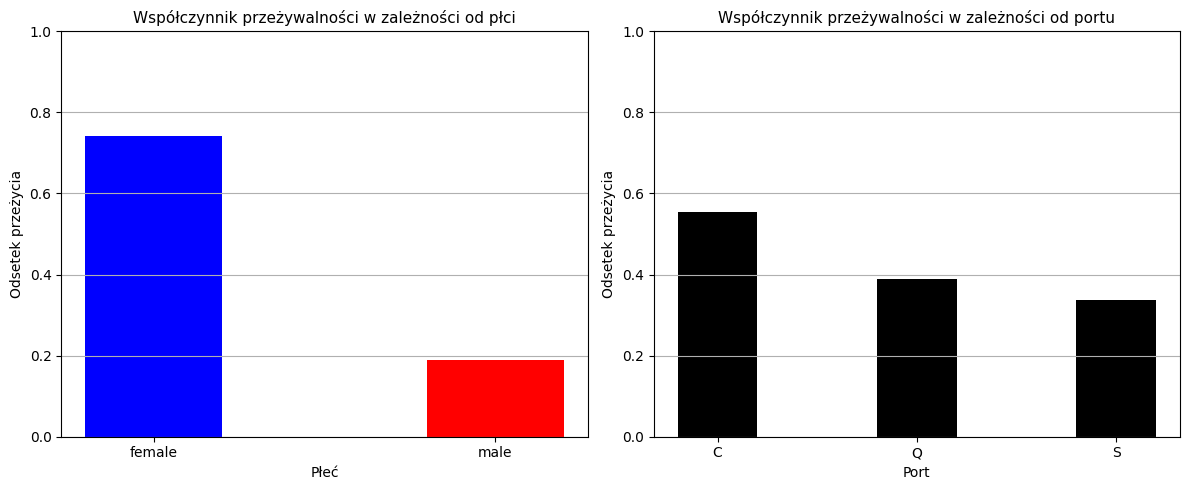

In [9]:
survival_by_gender = titanic_df.groupby("Sex")["Survived"].mean()
survival_by_embarked = (
    titanic_df.groupby("Embarked")["Survived"].mean().dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars1 = axes[0].bar(
    survival_by_gender.index,
    survival_by_gender.values,
    color=["blue", "red"],
    width=0.4,
)
axes[0].set_title("Współczynnik przeżywalności w zależności od płci", fontsize=11)
axes[0].set_xlabel("Płeć", fontsize=10)
axes[0].set_ylabel("Odsetek przeżycia", fontsize=10)
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y",)

bars2 = axes[1].bar(
    survival_by_embarked.index,
    survival_by_embarked.values,
    color="black",
    width=0.4,
)
axes[1].set_title("Współczynnik przeżywalności w zależności od portu", fontsize=11)
axes[1].set_xlabel("Port", fontsize=10)
axes[1].set_ylabel("Odsetek przeżycia", fontsize=10)
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y")

plt.tight_layout()

plt.show()

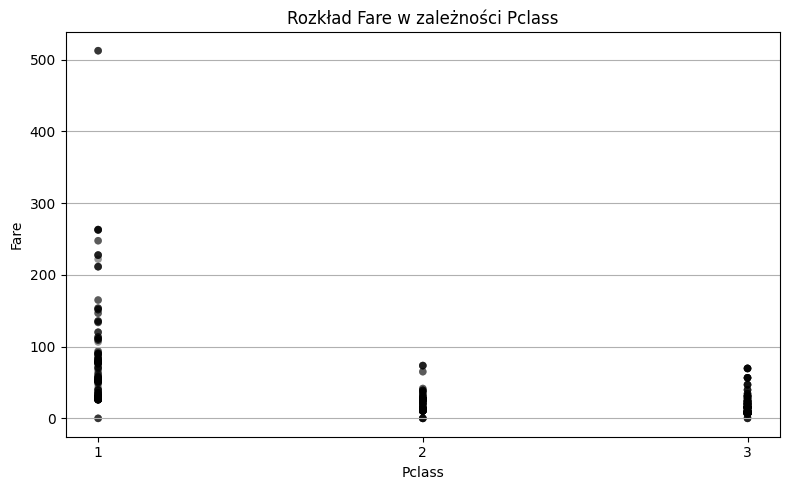

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(
    titanic_df["Pclass"],
    titanic_df["Fare"],
    alpha=0.4,
    color="black",
    edgecolors="none",
    s=30,
)

plt.title(
    "Rozkład Fare w zależności Pclass", fontsize=12
)
plt.xlabel("Pclass", fontsize=10)
plt.ylabel("Fare", fontsize=10)
plt.xticks([1, 2, 3])
plt.grid(axis="y")

plt.tight_layout()
plt.show()

#**Nowe Kolumny**

Kolumna IsAlone, 1 oznacza, że dla danego pasażera SibSp i Parch wynoszą 0, w przeciwnym wypadku wynosi 0

In [11]:
titanic_df["IsAlone"] = (
    (titanic_df["SibSp"] + titanic_df["Parch"]) == 0
).astype(int)

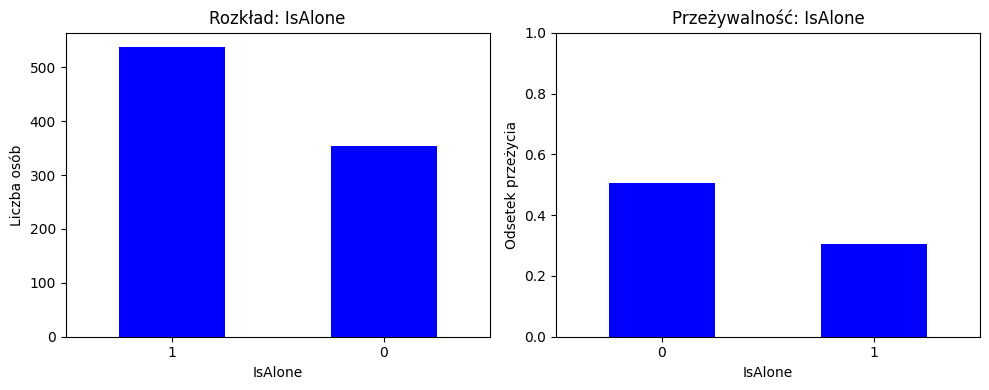

In [12]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
titanic_df["IsAlone"].value_counts().plot(kind="bar", color="blue", rot=0)
plt.title("Rozkład: IsAlone")
plt.xlabel("IsAlone")
plt.ylabel("Liczba osób")
plt.subplot(1, 2, 2)
titanic_df.groupby("IsAlone")["Survived"].mean().plot(kind="bar", color="blue", rot=0)
plt.title("Przeżywalność: IsAlone")
plt.xlabel("IsAlone")
plt.ylabel("Odsetek przeżycia")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Kolumna IsChild, 1 oznacza, że pasażer jest dzieckiem $Age \le 17$, w przeciwnym wypadku wynosi 0
Kolumna zostanie dodana później, po oczyszczeniu, ponieważ NaN oznaczałoby jako dziecko

#**Uzupełnienie brakujących danych**

Braki w kolumnie Age uzupełniamy medianą (asymetryczny rozkład)

Braki w kolumnie Fare uzupełniamy medianą z uwzględnieniem Pclass (asymetryczny rozkład)

Braki w kolumnie Embarked uzupełniamy dominantą (pojedyncze wartości/kategorialna)

In [13]:
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())

titanic_df['Fare'] = titanic_df['Fare'].fillna(titanic_df.groupby('Pclass')['Fare'].transform('median'))

titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])

print(titanic_df[['Fare', 'Age', 'Embarked']].isna().sum())

Fare        0
Age         0
Embarked    0
dtype: int64


Po uzupełnieniu wieku brakujących pasażerów dodajemu kolumnę IsChild

In [14]:
titanic_df["IsChild"] = (titanic_df["Age"] <= 17).astype(int)

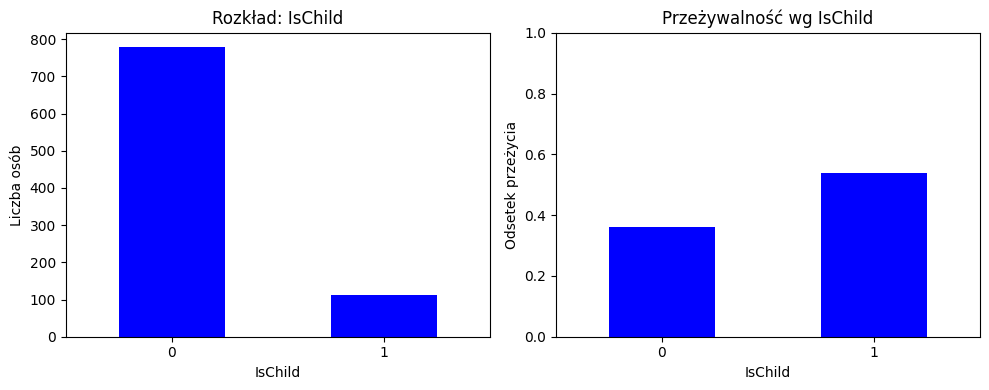

In [15]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
titanic_df["IsChild"].value_counts().plot(kind="bar", color="blue", rot=0)
plt.title("Rozkład: IsChild")
plt.xlabel("IsChild")
plt.ylabel("Liczba osób")
plt.subplot(1, 2, 2)
titanic_df.groupby("IsChild")["Survived"].mean().plot(kind="bar", color="blue", rot=0)
plt.title("Przeżywalność wg IsChild")
plt.xlabel("IsChild")
plt.ylabel("Odsetek przeżycia")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

#**Usunięcie zbędnych kolumn**


In [16]:
print("Wszystkie wiersze:", len(titanic_df))
print("Unikalne Name:", titanic_df["Name"].nunique())
print("Unikalne Ticket:", titanic_df["Ticket"].nunique())

Wszystkie wiersze: 891
Unikalne Name: 891
Unikalne Ticket: 681


Usuwamy kolumnę Name, ponieważ nie wpływa ona na przyżywaloność i służy tylko do identyfikacji

Usuwamy kolumnę Cabin, ponieważ mamy zbyt dużo brakujących wartości

Usuwamy kolumnę Ticket, ponieważ w większości to też unikalne numery i nie wnoszą żadnej wartości

In [17]:
titanic_df = titanic_df.drop(columns=["Name", "Ticket", "Cabin"])
print(titanic_df.head())

             Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked  \
PassengerId                                                                   
1                   0       3    male  22.0      1      0   7.2500        S   
2                   1       1  female  38.0      1      0  71.2833        C   
3                   1       3  female  26.0      0      0   7.9250        S   
4                   1       1  female  35.0      1      0  53.1000        S   
5                   0       3    male  35.0      0      0   8.0500        S   

             IsAlone  IsChild  
PassengerId                    
1                  0        0  
2                  0        0  
3                  1        0  
4                  0        0  
5                  1        0  


#**Kodowanie kolumn**


Kolumnę Sex zmieniamy na IsFemale dla czytelności i kodujemy zero-jedynkowo

In [18]:
titanic_df["Sex"] = titanic_df["Sex"].map({"male": 0, "female": 1})
titanic_df.rename(columns=
{
    "Sex": "IsFemale"
}, inplace=True)
print(titanic_df.head())

             Survived  Pclass  IsFemale   Age  SibSp  Parch     Fare Embarked  \
PassengerId                                                                     
1                   0       3         0  22.0      1      0   7.2500        S   
2                   1       1         1  38.0      1      0  71.2833        C   
3                   1       3         1  26.0      0      0   7.9250        S   
4                   1       1         1  35.0      1      0  53.1000        S   
5                   0       3         0  35.0      0      0   8.0500        S   

             IsAlone  IsChild  
PassengerId                    
1                  0        0  
2                  0        0  
3                  1        0  
4                  0        0  
5                  1        0  


Dla Embarked robimy One-Hot Encoding

In [19]:
titanic_df = pd.get_dummies(titanic_df, columns=["Embarked"], drop_first=False, dtype=int)

print(titanic_df.head())

             Survived  Pclass  IsFemale   Age  SibSp  Parch     Fare  IsAlone  \
PassengerId                                                                     
1                   0       3         0  22.0      1      0   7.2500        0   
2                   1       1         1  38.0      1      0  71.2833        0   
3                   1       3         1  26.0      0      0   7.9250        1   
4                   1       1         1  35.0      1      0  53.1000        0   
5                   0       3         0  35.0      0      0   8.0500        1   

             IsChild  Embarked_C  Embarked_Q  Embarked_S  
PassengerId                                               
1                  0           0           0           1  
2                  0           1           0           0  
3                  0           0           0           1  
4                  0           0           0           1  
5                  0           0           0           1  


#**Heatmap**

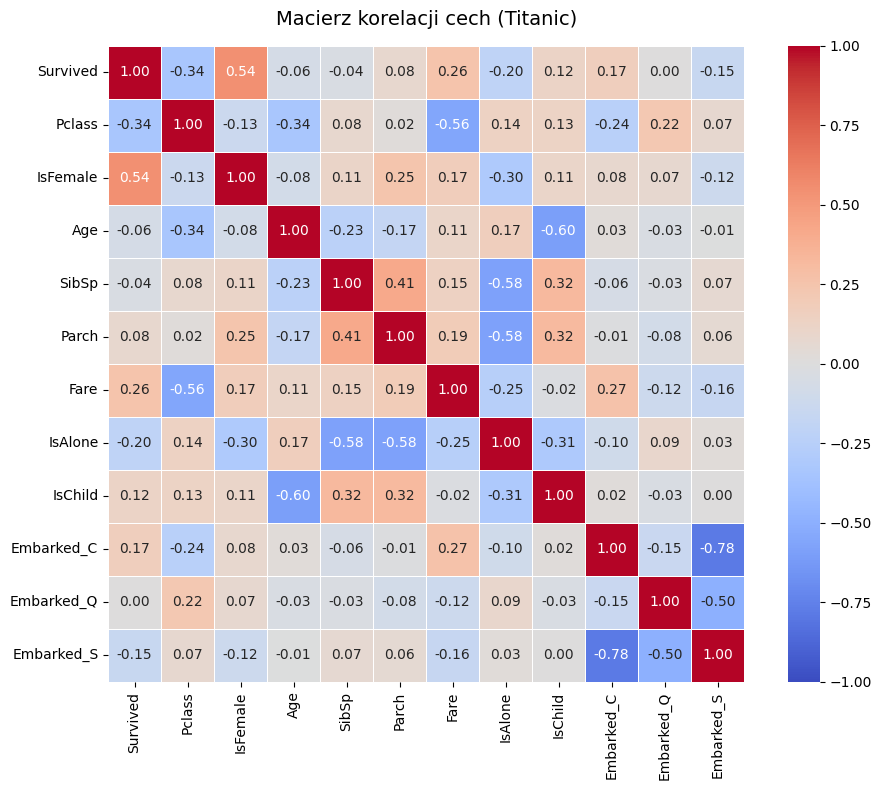

In [20]:
plt.figure(figsize=(10, 8))

corr_matrix = titanic_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)

plt.title("Macierz korelacji cech (Titanic)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()